### Load Libraries

In [1]:
library(tidyverse)
library(rasilabRtemplates)

── Attaching packages ─────────────────────────────────────── tidyverse 1.3.2 ──
✔ ggplot2 3.4.2      ✔ purrr   1.0.0 
✔ tibble  3.1.8      ✔ dplyr   1.0.10
✔ tidyr   1.2.1      ✔ stringr 1.5.0 
✔ readr   2.1.3      ✔ forcats 0.5.2 
Warning message:
“package ‘ggplot2’ was built under R version 4.2.3”
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()


### Plot CDF of Linkage Library

Rows: 13104 Columns: 4
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): barcode
dbl (3): insert_num, barcode_num, linkage_count

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


insert_num,barcode_num,barcode,linkage_count
<dbl>,<dbl>,<chr>,<dbl>
461,1,GCAGCCGCCCAACAGCGCCG,61
421,2,AACCACAAAGGGAGGAGCGC,58
570,3,GCGCACCCGACAAGGGCAAA,56
524,4,ACAGCGACCACAGCAAGCCC,54
448,5,GAGGGAAAGACCAGGCCGGG,53
⋮,⋮,⋮,⋮
1335,13100,AGCGAGGACGGGAAGGGGGG,1
1335,13101,GAACAGGACCAGGCAGGACG,1
1382,13102,GGAGGAACAAACGAGGCACC,1


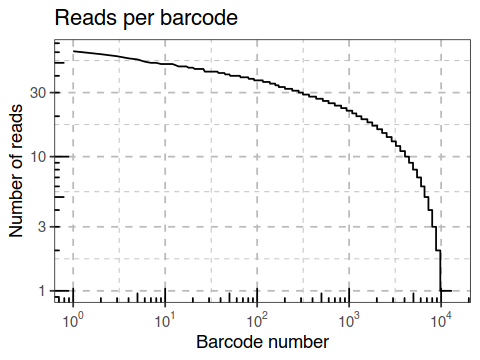

In [6]:
plot_data <- read_csv("../data/filtered_barcodes/filtered_barcodes_linkage.csv")

plot_data

plot_data %>% 
  arrange(desc(linkage_count)) %>%
  mutate(num = seq(1, dplyr::n())) %>% 
  ggplot(aes(x = num, y = linkage_count)) +
  geom_line() +
  theme_bw() +
  theme(panel.grid = element_line(color = "#BBBBBB", linetype = "dashed")) + 
  scale_x_log10(
    breaks = scales::trans_breaks("log10", function(x) 10^x),
    labels = scales::trans_format("log10", scales::math_format(10^.x))
  ) +
  scale_y_log10() +
  annotation_logticks()  +
  labs(x = "Barcode number", y = "Number of reads",
       title = "Reads per barcode") +
  NULL


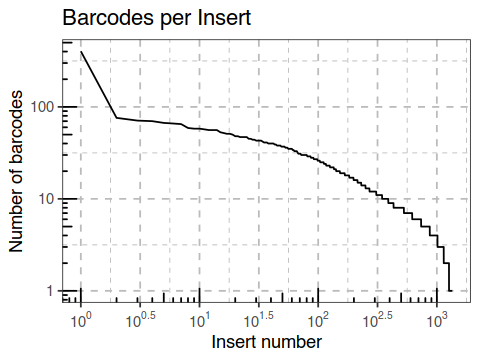

In [11]:
plot_data %>%
    group_by(insert_num)%>%
    summarize(n=n())%>%
    arrange(-n)%>%
    mutate(num = seq(1, dplyr::n())) %>%
    ggplot(aes(x = num, y = n)) +
    geom_line() +
    theme_bw() +
    theme(panel.grid = element_line(color = "#BBBBBB", linetype = "dashed")) + 
    scale_x_log10(
    breaks = scales::trans_breaks("log10", function(x) 10^x),
    labels = scales::trans_format("log10", scales::math_format(10^.x))
    ) +
    scale_y_log10() +
    annotation_logticks()  +
    labs(x = "Insert number", y = "Number of barcodes",
       title = "Barcodes per Insert") +
    NULL

In [20]:
plot_data %>%
    group_by(insert_num)%>%
    summarize(n=n())%>%
    arrange(-n)

insert_num,n
<dbl>,<int>
36,403
446,76
477,71
445,70
493,67
⋮,⋮
1344,1
1345,1
1350,1
